<a href="https://colab.research.google.com/github/mlinhneee/-sales-management-application/blob/main/SVM_TT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Ứng dụng SVM để phân loại spam mail/ sms

##1. Import thư viện

In [ ]:
# Thư viện xử lý dữ liệu
import numpy as np
import pandas as pd
# Thư viện trực quan hóa
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
# Thư viện xử lý văn bản
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
# Thư viện ML
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
# Thư viện chuyển vector thành văn bản số
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer
)
from sklearn.preprocessing import LabelEncoder
# Tải dữ liệu & cấu hình
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# Cấu hình hiển thị pandas
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_columns', 10)

# Cấu hình biểu đồ
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size']      = 12
sns.set_style("whitegrid")

# Cố định seed để kết quả tái lặp được
RANDOM_STATE = 42


##2. Nạp & Khám phá dữ liệu

In [ ]:
# Nạp dữ liệu
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

print("Nạp dữ liệu thành công!")
print(f"Kích thước ban đầu: {df.shape[0]} dòng x {df.shape[1]} cột")

# Xem dữ liệu thô
print("5 dòng đầu tiên của dữ liệu:")
df.head()

# Xóa các cột thừa
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

# Đổi tên cột cho dễ hiểu
df.columns = ['nhan', 'noi_dung']

print("Sau khi xử lý cột:")
print(f"Kích thước mới: {df.shape[0]} dòng x {df.shape[1]} cột")
df.head()

Nạp dữ liệu thành công!
Kích thước ban đầu: 5572 dòng x 5 cột
5 dòng đầu tiên của dữ liệu:
Sau khi xử lý cột:
Kích thước mới: 5572 dòng x 2 cột


,nhan,noi_dung
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


#2.1 Kiểm tra

In [ ]:
# thông tin cơ bản
print("THÔNG TIN TỔNG QUAN VỀ DATASET:")
print("-" * 40)
df.info()

# giá trị thiếu
print("SỐ LƯỢNG GIÁ TRỊ THIẾU THEO CỘT:")
print("-" * 40)
print(df.isnull().sum())
print(f"\nTổng số giá trị thiếu: {df.isnull().sum().sum()}")

# dữ liệu trùng lặp (trùng thì xóa)
so_dong_trung = df.duplicated().sum()
print(f"Số dòng trùng lặp phát hiện: {so_dong_trung}")

if so_dong_trung > 0:
    df = df.drop_duplicates()
    df = df.reset_index(drop=True)
    print(f"Đã xóa {so_dong_trung} dòng trùng lặp.")
    print(f"Kích thước sau khi xóa: {df.shape[0]} dòng x {df.shape[1]} cột")
else:
    print("Không có dòng trùng lặp.")

THÔNG TIN TỔNG QUAN VỀ DATASET:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   nhan      5572 non-null   object
 1   noi_dung  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
SỐ LƯỢNG GIÁ TRỊ THIẾU THEO CỘT:
----------------------------------------
nhan        0
noi_dung    0
dtype: int64

Tổng số giá trị thiếu: 0
Số dòng trùng lặp phát hiện: 403
Đã xóa 403 dòng trùng lặp.
Kích thước sau khi xóa: 5169 dòng x 2 cột


# 2.2 Thống kê

In [ ]:
# phân phối nhãn
ti_le = df['nhan'].value_counts(normalize=True) * 100
phan_phoi = df['nhan'].value_counts()

print("PHÂN PHỐI NHÃN TRONG DATASET:")
print("-" * 40)
print(f"{'Nhãn':<10} {'Số lượng':<12} {'Tỉ lệ (%)'}")
print("-" * 40)
for nhan in phan_phoi.index:
    print(f"{nhan:<10} {phan_phoi[nhan]:<12} {ti_le[nhan]:.2f}%")
print("-" * 40)
print(f"{'Tổng cộng':<10} {phan_phoi.sum():<12} 100.00%")

#thêm cột độ dài tin nhắn
df['do_dai'] = df['noi_dung'].apply(len)
df['so_tu']  = df['noi_dung'].apply(lambda x: len(x.split()))

print("Đã thêm cột độ dài tin nhắn:")
df[['nhan', 'noi_dung', 'do_dai', 'so_tu']].head(8)

# mô tả độ dài
print("THỐNG KÊ ĐỘ DÀI TIN NHẮN THEO NHÃN:")
print("-" * 50)
thong_ke = df.groupby('nhan')[['do_dai', 'so_tu']].agg(
    ['mean', 'min', 'max']
).round(2)

thong_ke.columns = [
    'Độ dài TB', 'Độ dài Min', 'Độ dài Max',
    'Số từ TB',  'Số từ Min',  'Số từ Max'
]
print(thong_ke)


PHÂN PHỐI NHÃN TRONG DATASET:
----------------------------------------
Nhãn       Số lượng     Tỉ lệ (%)
----------------------------------------
ham        4516         87.37%
spam       653          12.63%
----------------------------------------
Tổng cộng  5169         100.00%
Đã thêm cột độ dài tin nhắn:
THỐNG KÊ ĐỘ DÀI TIN NHẮN THEO NHÃN:
--------------------------------------------------
      Độ dài TB  Độ dài Min  Độ dài Max  Số từ TB  Số từ Min  Số từ Max
nhan                                                                   
ham       70.46           2         910     14.13          1        171
spam     137.89          13         224     23.68          2         35


##3. Trực quan hóa và phân tích dữ liệu

###3.1 Biểu đồ phân phối nhãn

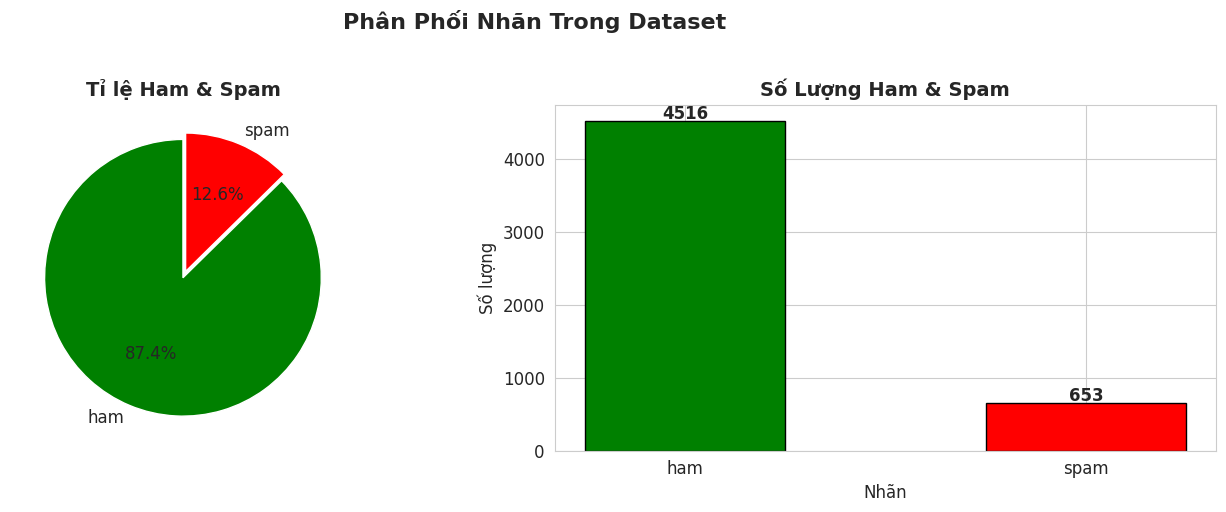

   Ham chiếm 87.4%, Spam chiếm 12.6%


In [ ]:
# Biểu đồ tròn và cột thể hiện tỉ lệ ham/spam
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dữ liệu
nhan_counts = df['nhan'].value_counts()
mau_sac     = ['green', 'red']  # quy ước: xanh = ham, đỏ = spam

# Biểu đồ tròn
axes[0].pie(
    nhan_counts,
    labels    = nhan_counts.index,
    autopct   = '%1.1f%%',
    colors    = mau_sac,
    startangle= 90,
    explode   = (0, 0.05)
)
axes[0].set_title('Tỉ lệ Ham & Spam', fontsize=14, fontweight='bold')

# Biểu đồ cột
bars = axes[1].bar(
    nhan_counts.index,
    nhan_counts.values,
    color  = mau_sac,
    edgecolor = 'black',
    width  = 0.5
)
# Thêm số liệu lên đầu mỗi cột
for bar, val in zip(bars, nhan_counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        str(val),
        ha='center', fontsize=12, fontweight='bold'
    )
axes[1].set_title('Số Lượng Ham & Spam', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nhãn')
axes[1].set_ylabel('Số lượng')

plt.suptitle('Phân Phối Nhãn Trong Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"   Ham chiếm {nhan_counts['ham']/nhan_counts.sum()*100:.1f}%,"
      f" Spam chiếm {nhan_counts['spam']/nhan_counts.sum()*100:.1f}%")


###3.2 Phân phối độ dài tin nhắn

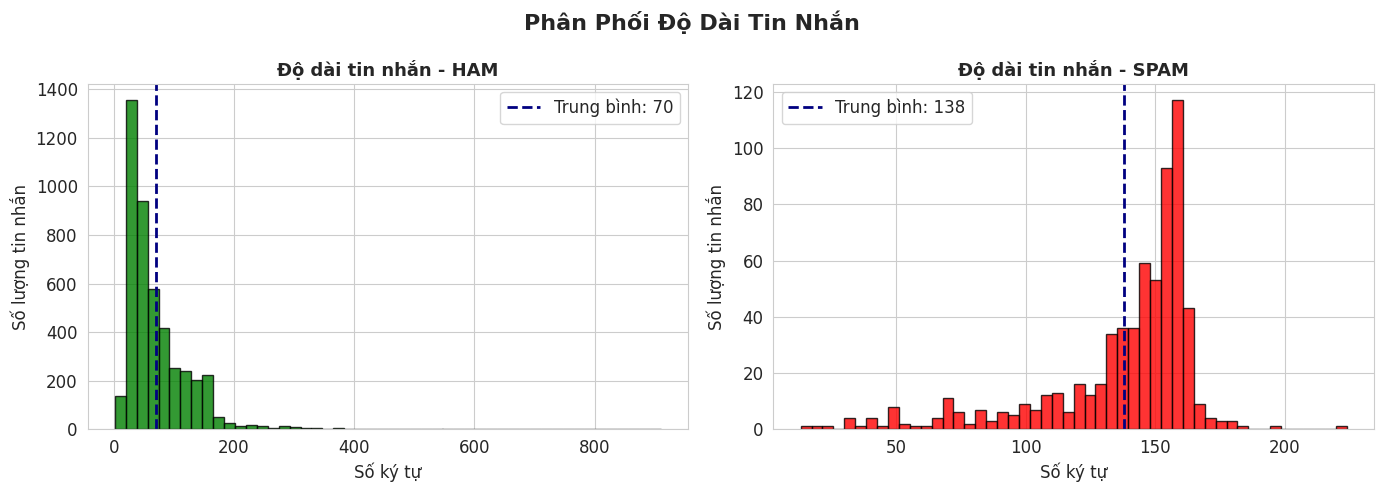

In [ ]:
# Biểu đồ tần suất độ dài ký tự ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, nhan, mau in zip(axes, ['ham', 'spam'], ['green', 'red']):
    du_lieu = df[df['nhan'] == nhan]['do_dai']
    ax.hist(du_lieu, bins=50, color=mau, edgecolor='black', alpha=0.8)
    ax.axvline(du_lieu.mean(), color='navy', linestyle='--',
               linewidth=2, label=f'Trung bình: {du_lieu.mean():.0f}')
    ax.set_title(f'Độ dài tin nhắn - {nhan.upper()}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Số ký tự')
    ax.set_ylabel('Số lượng tin nhắn')
    ax.legend()

plt.suptitle('Phân Phối Độ Dài Tin Nhắn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

###3.3 Phân phối số từ

/tmp/ipykernel_168/1653152393.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_168/1653152393.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


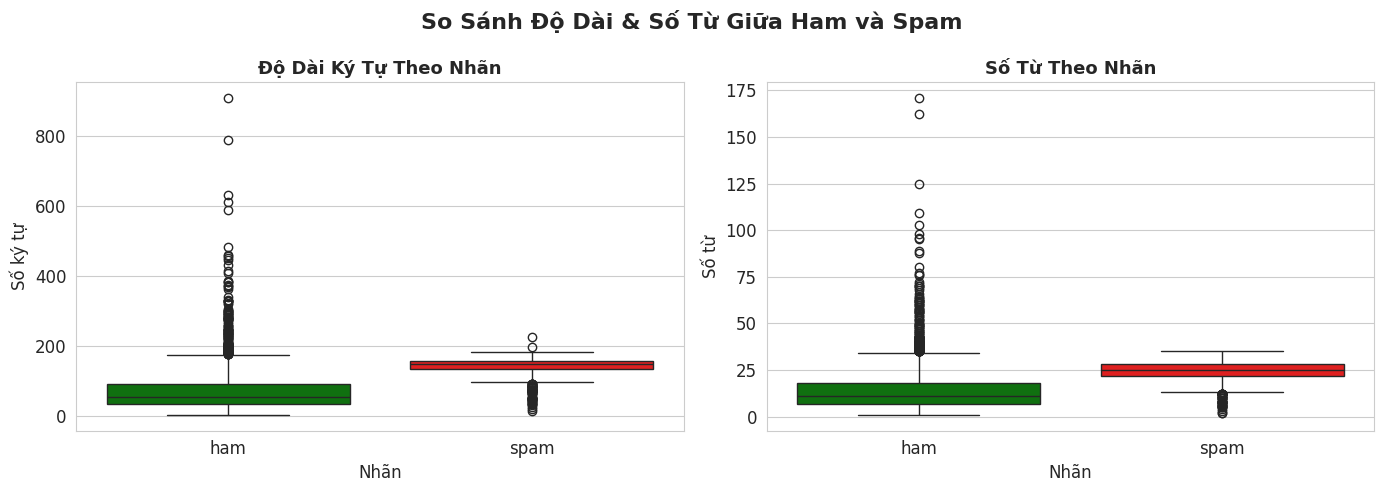

In [ ]:
# Biểu đồ hộp số từ theo nhãn ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ hộp độ dài ký tự
sns.boxplot(
    data    = df,
    x       = 'nhan',
    y       = 'do_dai',
    palette = {'ham': 'green', 'spam': 'red'},
    ax      = axes[0]
)
axes[0].set_title('Độ Dài Ký Tự Theo Nhãn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nhãn')
axes[0].set_ylabel('Số ký tự')

# Boxplot số từ
sns.boxplot(
    data    = df,
    x       = 'nhan',
    y       = 'so_tu',
    palette = {'ham': 'green', 'spam': 'red'},
    ax      = axes[1]
)
axes[1].set_title('Số Từ Theo Nhãn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nhãn')
axes[1].set_ylabel('Số từ')

plt.suptitle('So Sánh Độ Dài & Số Từ Giữa Ham và Spam',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

###3.4 Thống kê tin nhắn ham

In [ ]:
from collections import Counter
import string

# lọc dataframe cho các tin nhắn ham
df_ham = df[df['nhan'] == 'ham']

# khởi chạy công cụ
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

# xử lý văn bản
def process_text(text):
    # chuyển sang chữ thường để quét
    text = text.lower()
    # xóa dấu câu
    text = text.translate(str.maketrans('', '', string.punctuation))
    # phân tách và lọc từ
    tokens = word_tokenize(text)
    # lọc (đảm bảo các từ là chữ cái)
    cleaned = [stemmer.stem(word) for word in tokens if word not in stop_words and word.isalpha()]
    return cleaned

# xử lý tin nhắn hợp lệ
all_ham_words = []
for msg in df_ham['noi_dung']:
    all_ham_words.extend(process_text(msg))

# tính tần suất sử dụng
ham_counts = Counter(all_ham_words)

# chuyển và sắp xếp
df_ham_freq = pd.DataFrame(ham_counts.most_common(), columns=['Từ', 'Số lần xuất hiện'])
df_ham_freq.insert(0, 'Số thứ tự', range(1, len(df_ham_freq) + 1))

print("Bảng thống kê tần suất từ trong tin nhắn HAM:")
display(df_ham_freq.head(30))

Bảng thống kê tần suất từ trong tin nhắn HAM:


,Số thứ tự,Từ,Số lần xuất hiện
0,1,u,878
1,2,im,435
2,3,go,401
3,4,get,352
4,5,come,272
5,6,ltgt,254
6,7,ok,246
7,8,dont,242
8,9,got,237
9,10,like,232


###3.5 Thống kê tin nhắn spam

In [ ]:
from collections import Counter
import string

df_spam = df[df['nhan'] == 'spam']

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def process_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    cleaned = [stemmer.stem(word) for word in tokens if word not in stop_words and word.isalpha()]
    return cleaned

all_spam_words = []
for msg in df_spam['noi_dung']:
    all_spam_words.extend(process_text(msg))

spam_counts = Counter(all_spam_words)

df_spam_freq = pd.DataFrame(spam_counts.most_common(), columns=['Từ', 'Số lần xuất hiện'])
df_spam_freq.insert(0, 'Số thứ tự', range(1, len(df_spam_freq) + 1))

print("Bảng thống kê tần suất từ trong tin nhắn SPAM:")
display(df_spam_freq.head(30))



Bảng thống kê tần suất từ trong tin nhắn SPAM:


,Số thứ tự,Từ,Số lần xuất hiện
0,1,call,321
1,2,free,188
2,3,txt,137
3,4,u,123
4,5,text,121
5,6,ur,119
6,7,mobil,114
7,8,stop,103
8,9,repli,100
9,10,claim,98


### 3.6 Biểu đồ & so sánh

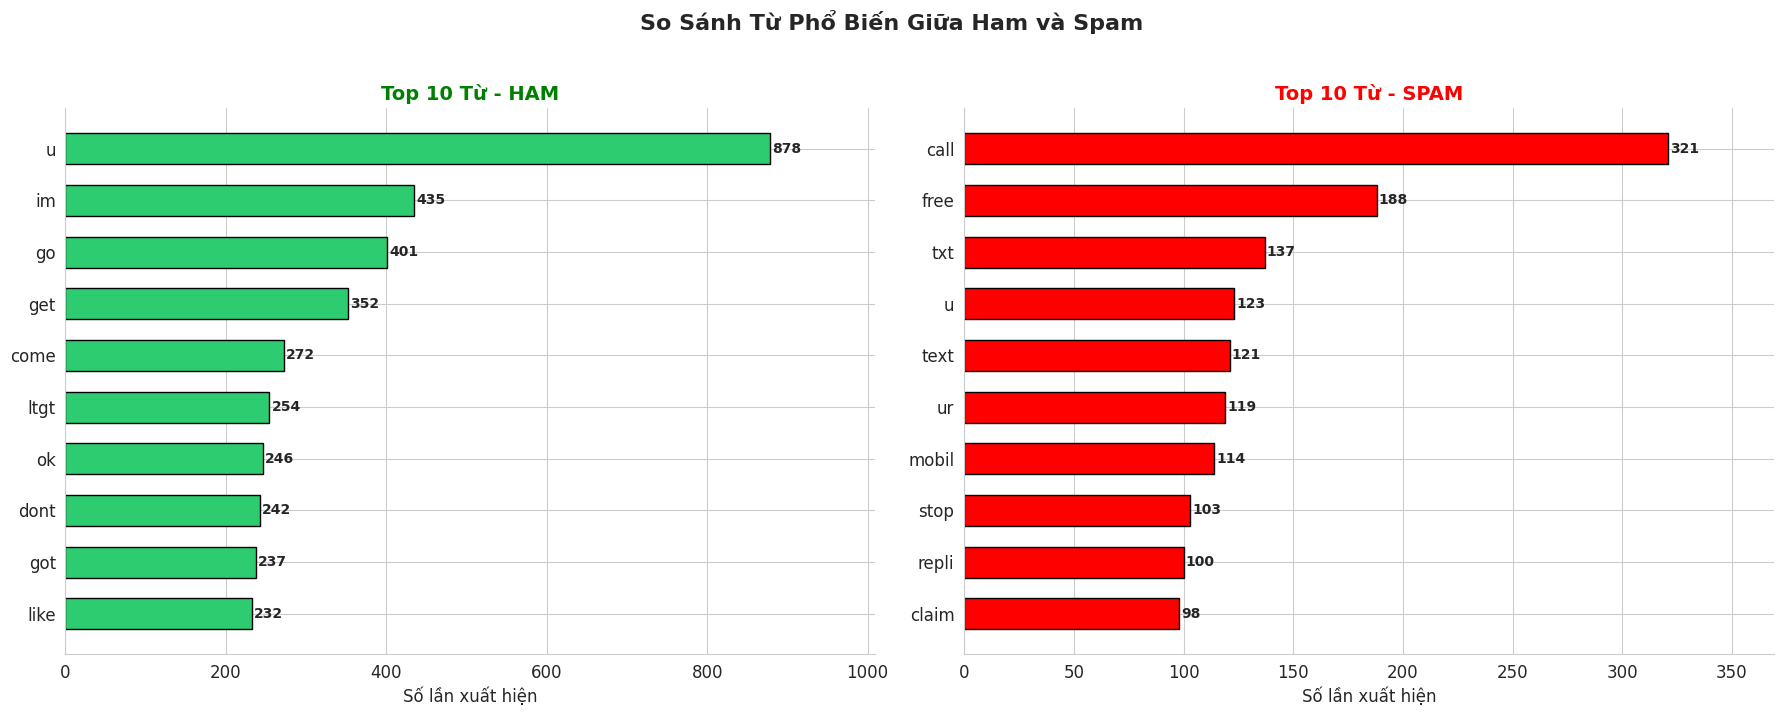

In [ ]:
# Lấy top 10 từ mỗi loại để so sánh
top10_ham  = df_ham_freq.head(10)
top10_spam = df_spam_freq.head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Ham
top10_ham_sorted = top10_ham.sort_values('Số lần xuất hiện')
axes[0].barh(
    top10_ham_sorted['Từ'],
    top10_ham_sorted['Số lần xuất hiện'],
    color='#2ecc71', edgecolor='black', height=0.6
)
for i, (val, y) in enumerate(zip(
    top10_ham_sorted['Số lần xuất hiện'],
    range(len(top10_ham_sorted))
)):
    axes[0].text(val + 3, y, str(val),
                 va='center', fontsize=10, fontweight='bold')

axes[0].set_title('Top 10 Từ - HAM',
                  fontsize=14, fontweight='bold', color='green')
axes[0].set_xlabel('Số lần xuất hiện')
axes[0].set_xlim(0, top10_ham_sorted['Số lần xuất hiện'].max() * 1.15)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Spam
top10_spam_sorted = top10_spam.sort_values('Số lần xuất hiện')
axes[1].barh(
    top10_spam_sorted['Từ'],
    top10_spam_sorted['Số lần xuất hiện'],
    color='red', edgecolor='black', height=0.6
)
for i, (val, y) in enumerate(zip(
    top10_spam_sorted['Số lần xuất hiện'],
    range(len(top10_spam_sorted))
)):
    axes[1].text(val + 1, y, str(val),
                 va='center', fontsize=10, fontweight='bold')

axes[1].set_title('Top 10 Từ - SPAM',
                  fontsize=14, fontweight='bold', color='red')
axes[1].set_xlabel('Số lần xuất hiện')
axes[1].set_xlim(0, top10_spam_sorted['Số lần xuất hiện'].max() * 1.15)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('So Sánh Từ Phổ Biến Giữa Ham và Spam',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



##4. Xử lý văn bản

###4.1 Mã hóa

In [ ]:
# qui ước: ham -> 0, spam -> 1
df['nhan_so'] = df['nhan'].map({'ham': 0, 'spam': 1})

print("Kết quả mã hóa nhãn:")
print(df[['nhan', 'nhan_so']].head(10))
print(f"\nham  → 0: {(df['nhan_so'] == 0).sum()} tin nhắn")
print(f"spam → 1: {(df['nhan_so'] == 1).sum()} tin nhắn")

Kết quả mã hóa nhãn:
   nhan  nhan_so
0   ham        0
1   ham        0
2  spam        1
3   ham        0
4   ham        0
5  spam        1
6   ham        0
7   ham        0
8  spam        1
9  spam        1

ham  → 0: 4516 tin nhắn
spam → 1: 653 tin nhắn


###4.2 Làm sạch

In [ ]:
#làm sạch văn bản
def lam_sach_van_ban(text):


    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()

    return text

In [ ]:
# áp dụng lên toàn bộ file csv
df['noi_dung_sach'] = df['noi_dung'].apply(lam_sach_van_ban)

# so sánh
print("So sánh trước và sau khi làm sạch:")
print("-" * 60)
for i in range(3):
    print(f"\n[Tin nhắn {i+1}] Nhãn: {df['nhan'][i]}")
    print(f"  Trước: {df['noi_dung'][i]}")
    print(f"  Sau  : {df['noi_dung_sach'][i]}")

So sánh trước và sau khi làm sạch:
------------------------------------------------------------

[Tin nhắn 1] Nhãn: ham
  Trước: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  Sau  : go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat

[Tin nhắn 2] Nhãn: ham
  Trước: Ok lar... Joking wif u oni...
  Sau  : ok lar joking wif u oni

[Tin nhắn 3] Nhãn: spam
  Trước: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  Sau  : free entry in  a wkly comp to win fa cup final tkts st may  text fa to  to receive entry questionstd txt ratetcs apply overs


###4.3 Xem dữ liệu sau khi xử lý

In [ ]:
print(f"Tổng số tin nhắn  : {len(df)}")
print(f"Số tin nhắn ham   : {(df['nhan_so'] == 0).sum()}")
print(f"Số tin nhắn spam  : {(df['nhan_so'] == 1).sum()}")
print(f"\nCột hiện có: {list(df.columns)}")
df[['nhan', 'nhan_so', 'noi_dung', 'noi_dung_sach']].head()

Tổng số tin nhắn  : 5169
Số tin nhắn ham   : 4516
Số tin nhắn spam  : 653

Cột hiện có: ['nhan', 'noi_dung', 'do_dai', 'so_tu', 'nhan_so', 'noi_dung_sach']


,nhan,nhan_so,noi_dung,noi_dung_sach
0,ham,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...",go until jurong point crazy available only in bugis n great world la e buffet cine there got amo...
1,ham,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...,free entry in a wkly comp to win fa cup final tkts st may text fa to to receive entry questio...
3,ham,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,0,"Nah I don't think he goes to usf, he lives around here though",nah i dont think he goes to usf he lives around here though


#5. Trích xuất đặc trưng

##5.1 Chia thành tập huấn luyện và tập kiểm tra

In [ ]:
from sklearn.model_selection import train_test_split

X = df['noi_dung_sach']
y = df['nhan_so']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = RANDOM_STATE,
    stratify     = y        # đảm bảo tỉ lệ ham/spam giống nhau ở cả 2 tập
)

In [ ]:
# in kết quả sau khi chia tập
print(f"Tổng số mẫu      : {len(df)}")
print(f"Tập huấn luyện   : {len(X_train)} mẫu ({len(X_train)/len(df)*100:.1f}%)")
print(f"Tập kiểm tra     : {len(X_test)}  mẫu ({len(X_test)/len(df)*100:.1f}%)")
print(f"\nPhân phối tập huấn luyện:")
print(f"  Ham  : {(y_train == 0).sum()} mẫu")
print(f"  Spam : {(y_train == 1).sum()} mẫu")
print(f"\nPhân phối tập kiểm tra:")
print(f"  Ham  : {(y_test == 0).sum()} mẫu")
print(f"  Spam : {(y_test == 1).sum()} mẫu")

Tổng số mẫu      : 5169
Tập huấn luyện   : 4135 mẫu (80.0%)
Tập kiểm tra     : 1034  mẫu (20.0%)

Phân phối tập huấn luyện:
  Ham  : 3613 mẫu
  Spam : 522 mẫu

Phân phối tập kiểm tra:
  Ham  : 903 mẫu
  Spam : 131 mẫu


###5.3 Xây dựng TF-DF

In [ ]:
# --- Khởi tạo và huấn luyện TF-IDF ---
tfidf = TfidfVectorizer(
    max_features = 5000,              # giữ 5000 từ quan trọng nhất
    ngram_range  = (1, 2),            # xét đơn từ và cặp từ
    min_df       = 2,                 # bỏ từ xuất hiện < 2 lần
    stop_words   = 'english'          # loại stopwords tiếng anh
)

# Học từ tập huấn luyện và chuyển đổi
X_train_tfidf = tfidf.fit_transform(X_train)

# Chỉ chuyển đổi tập kiểm tra (không học lại)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Kích thước tập huấn luyện : {X_train_tfidf.shape}")
print(f"Kích thước tập kiểm tra   : {X_test_tfidf.shape}")
print(f"Số lượng đặc trưng        : {X_train_tfidf.shape[1]}")

Kích thước tập huấn luyện : (4135, 5000)
Kích thước tập kiểm tra   : (1034, 5000)
Số lượng đặc trưng        : 5000


In [ ]:
# Xem top 20 từ quan trọng nhất theo từng nhãn
ten_dac_trung = tfidf.get_feature_names_out()

# Tách chỉ số của ham và spam trong tập huấn luyện
chi_so_ham  = y_train[y_train == 0].index
chi_so_spam = y_train[y_train == 1].index

# Lấy vị trí trong ma trận
X_train_df = X_train.reset_index(drop=True)
vi_tri_ham  = [i for i, idx in enumerate(X_train.index) if idx in chi_so_ham]
vi_tri_spam = [i for i, idx in enumerate(X_train.index) if idx in chi_so_spam]

# Tính trung bình TF-IDF riêng cho ham và spam
tb_ham  = X_train_tfidf[vi_tri_ham].mean(axis=0).A1
tb_spam = X_train_tfidf[vi_tri_spam].mean(axis=0).A1

# Tạo dataframe cho ham
df_ham_tfidf = pd.DataFrame({
    'Từ / Cụm từ'     : ten_dac_trung,
    'Trọng số TF-IDF' : tb_ham
}).sort_values('Trọng số TF-IDF', ascending=False).reset_index(drop=True)
df_ham_tfidf.insert(0, 'Số thứ tự', range(1, len(df_ham_tfidf) + 1))

# Tạo dataframe cho spam
df_spam_tfidf = pd.DataFrame({
    'Từ / Cụm từ'     : ten_dac_trung,
    'Trọng số TF-IDF' : tb_spam
}).sort_values('Trọng số TF-IDF', ascending=False).reset_index(drop=True)
df_spam_tfidf.insert(0, 'Số thứ tự', range(1, len(df_spam_tfidf) + 1))

print("Top 20 từ quan trọng nhất trong tin nhắn HAM:")
display(df_ham_tfidf.head(20))

print("\nTop 20 từ quan trọng nhất trong tin nhắn SPAM:")
display(df_spam_tfidf.head(20))


Top 20 từ quan trọng nhất trong tin nhắn HAM:


,Số thứ tự,Từ / Cụm từ,Trọng số TF-IDF
0,1,im,0.020294
1,2,ok,0.017343
2,3,come,0.013066
3,4,ltgt,0.012246
4,5,just,0.012231
5,6,ill,0.011909
6,7,like,0.011822
7,8,got,0.011541
8,9,dont,0.011519
9,10,know,0.011330



Top 20 từ quan trọng nhất trong tin nhắn SPAM:


,Số thứ tự,Từ / Cụm từ,Trọng số TF-IDF
0,1,free,0.042463
1,2,text,0.029512
2,3,txt,0.027977
3,4,mobile,0.027639
4,5,stop,0.027054
5,6,ur,0.025443
6,7,claim,0.024868
7,8,reply,0.024781
8,9,prize,0.023151
9,10,new,0.019566


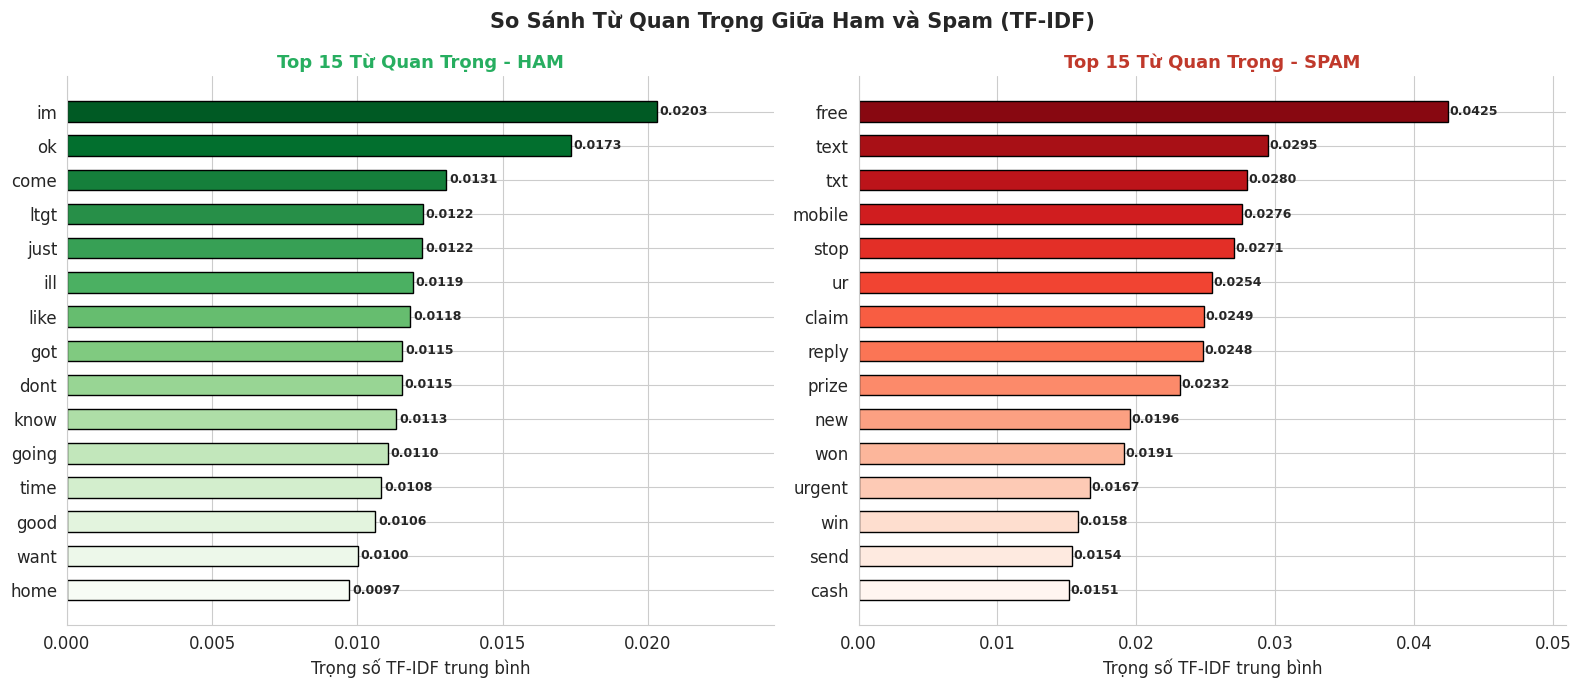

In [ ]:
# Biểu đồ so sánh top 15 từ Ham vs Spam
top15_ham  = df_ham_tfidf.head(15).sort_values('Trọng số TF-IDF')
top15_spam = df_spam_tfidf.head(15).sort_values('Trọng số TF-IDF')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Biểu đồ Ham
bars_ham = axes[0].barh(
    top15_ham['Từ / Cụm từ'],
    top15_ham['Trọng số TF-IDF'],
    color     = plt.cm.Greens(
        [i / len(top15_ham) for i in range(len(top15_ham))]
    ),
    edgecolor = 'black',
    height    = 0.6
)
for bar, val in zip(bars_ham, top15_ham['Trọng số TF-IDF']):
    axes[0].text(
        bar.get_width() + 0.0001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', ha='left',
        fontsize=9, fontweight='bold'
    )
axes[0].set_title('Top 15 Từ Quan Trọng - HAM',
                  fontsize=13, fontweight='bold', color='#27ae60')
axes[0].set_xlabel('Trọng số TF-IDF trung bình')
axes[0].set_xlim(0, top15_ham['Trọng số TF-IDF'].max() * 1.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Biểu đồ Spam
bars_spam = axes[1].barh(
    top15_spam['Từ / Cụm từ'],
    top15_spam['Trọng số TF-IDF'],
    color     = plt.cm.Reds(
        [i / len(top15_spam) for i in range(len(top15_spam))]
    ),
    edgecolor = 'black',
    height    = 0.6
)
for bar, val in zip(bars_spam, top15_spam['Trọng số TF-IDF']):
    axes[1].text(
        bar.get_width() + 0.0001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', ha='left',
        fontsize=9, fontweight='bold'
    )
axes[1].set_title('Top 15 Từ Quan Trọng - SPAM',
                  fontsize=13, fontweight='bold', color='#c0392b')
axes[1].set_xlabel('Trọng số TF-IDF trung bình')
axes[1].set_xlim(0, top15_spam['Trọng số TF-IDF'].max() * 1.2)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('So Sánh Từ Quan Trọng Giữa Ham và Spam (TF-IDF)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()



#6. Xây dựng mô hình SVM

##6.1 Huấn luyện SVM Kernel Linear

In [ ]:
svm_linear = SVC(
    kernel       = 'linear',
    C            = 1.0,
    class_weight = 'balanced',   # xử lý mất cân bằng dữ liệu
    random_state = RANDOM_STATE
)
svm_linear.fit(X_train_tfidf, y_train)

SVC(class_weight='balanced', kernel='linear', random_state=42)

##6.2 Huấn luyện SVM Kernel RBF

In [ ]:
svm_rbf = SVC(
    kernel       = 'rbf',
    C            = 1.0,
    gamma        = 'scale',
    class_weight = 'balanced',
    random_state = RANDOM_STATE
)
svm_rbf.fit(X_train_tfidf, y_train)

SVC(class_weight='balanced', random_state=42)

##6.3 Huấn luyện SVM Kernel Polynomial

In [ ]:
svm_poly = SVC(
    kernel       = 'poly',
    C            = 1.0,
    degree       = 3,
    class_weight = 'balanced',
    random_state = RANDOM_STATE
)
svm_poly.fit(X_train_tfidf, y_train)

SVC(class_weight='balanced', kernel='poly', random_state=42)

##6.4 Huấn luyện SVM Kernel Sigmoid

In [ ]:
svm_sigmoid = SVC(
    kernel       = 'sigmoid',
    C            = 1.0,
    class_weight = 'balanced',
    random_state = RANDOM_STATE
)
svm_sigmoid.fit(X_train_tfidf, y_train)

SVC(class_weight='balanced', kernel='sigmoid', random_state=42)

##6.5 Dự đoán và so sánh

In [ ]:
# Dự đoán trên tập kiểm tra
y_pred_linear  = svm_linear.predict(X_test_tfidf)
y_pred_rbf     = svm_rbf.predict(X_test_tfidf)
y_pred_poly    = svm_poly.predict(X_test_tfidf)
y_pred_sigmoid = svm_sigmoid.predict(X_test_tfidf)

print(f"Số mẫu kiểm tra: {len(y_test)}")

Số mẫu kiểm tra: 1034


In [ ]:
# So sánh kết quả
from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
# --- Tính các chỉ số đánh giá ---
danh_sach_kernel = {
    'Linear'     : y_pred_linear,
    'RBF'        : y_pred_rbf,
    'Polynomial' : y_pred_poly,
    'Sigmoid'    : y_pred_sigmoid
}

ket_qua = []
for ten_kernel, y_pred in danh_sach_kernel.items():
    ket_qua.append({
        'Kernel'       : ten_kernel,
        'Accuracy'     : accuracy_score(y_test, y_pred),
        'Precision'    : precision_score(y_test, y_pred),
        'Recall'       : recall_score(y_test, y_pred),
        'F1-Score'     : f1_score(y_test, y_pred)
    })

df_ket_qua = pd.DataFrame(ket_qua)
df_ket_qua.set_index('Kernel', inplace=True)
df_ket_qua = df_ket_qua.round(4)

print("BẢNG SO SÁNH KẾT QUẢ CÁC KERNEL SVM:")
print("-" * 60)
display(df_ket_qua)

BẢNG SO SÁNH KẾT QUẢ CÁC KERNEL SVM:
------------------------------------------------------------


,Accuracy,Precision,Recall,F1-Score
Kernel,,,,
Linear,0.9768,0.9421,0.8702,0.9048
RBF,0.9768,0.9908,0.8244,0.9000
Polynomial,0.9323,1.0000,0.4656,0.6354
Sigmoid,0.9720,0.8984,0.8779,0.8880


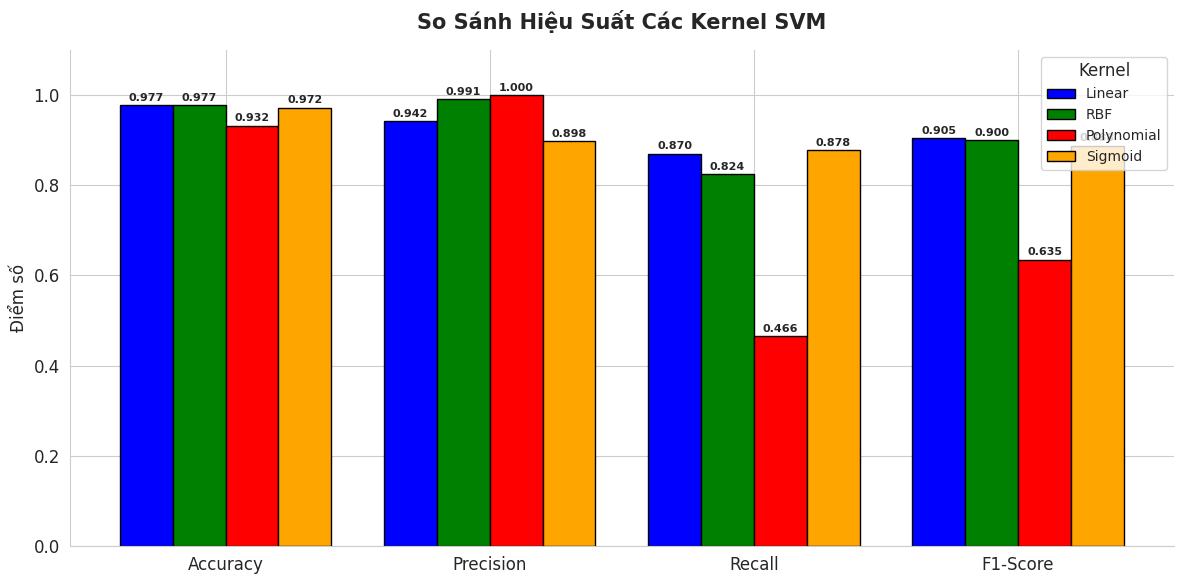


=> Kernel tốt nhất theo F1-Score: Linear
   F1-Score: 0.9048


In [ ]:
# Biểu đồ so sánh các chỉ số
fig, ax = plt.subplots(figsize=(12, 6))

x      = np.arange(len(df_ket_qua.columns))
width  = 0.2
mau    = ['blue', 'green', 'red', 'orange']

for i, (kernel, row) in enumerate(df_ket_qua.iterrows()):
    bars = ax.bar(
        x + i * width,
        row.values,
        width,
        label     = kernel,
        color     = mau[i],
        edgecolor = 'black'
    )
    # Thêm số liệu lên đầu mỗi cột
    for bar, val in zip(bars, row.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

ax.set_title('So Sánh Hiệu Suất Các Kernel SVM',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_ket_qua.columns, fontsize=12)
ax.set_ylabel('Điểm số', fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(title='Kernel', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# In ra kernel tốt nhất
kernel_tot_nhat = df_ket_qua['F1-Score'].idxmax()
print(f"\n=> Kernel tốt nhất theo F1-Score: {kernel_tot_nhat}")
print(f"   F1-Score: {df_ket_qua.loc[kernel_tot_nhat, 'F1-Score']:.4f}")


##7. Đánh giá mô hình


##7.1 Báo cáo phân loại chi tiết

In [ ]:
print("BÁO CÁO PHÂN LOẠI CHI TIẾT - SVM KERNEL LINEAR:")
print(classification_report(
    y_test,
    y_pred_linear,
    target_names = ['Ham (0)', 'Spam (1)']
))

BÁO CÁO PHÂN LOẠI CHI TIẾT - SVM KERNEL LINEAR:
              precision    recall  f1-score   support

     Ham (0)       0.98      0.99      0.99       903
    Spam (1)       0.94      0.87      0.90       131

    accuracy                           0.98      1034
   macro avg       0.96      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



##7.2 Ma trận nhầm lẫn

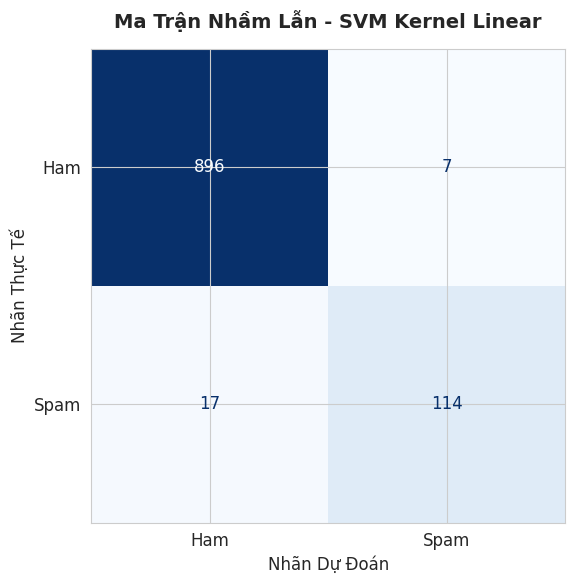

In [ ]:
# Vẽ ma trận
cm = confusion_matrix(y_test, y_pred_linear)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = ['Ham', 'Spam']
)
disp.plot(
    cmap          = 'Blues',
    colorbar      = False,
    ax            = ax
)

# Chỉnh tiêu đề và nhãn
ax.set_title('Ma Trận Nhầm Lẫn - SVM Kernel Linear',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Nhãn Dự Đoán', fontsize=12)
ax.set_ylabel('Nhãn Thực Tế', fontsize=12)

plt.tight_layout()
plt.show()


###7.3 Biểu đồ các chỉ số đánh giá

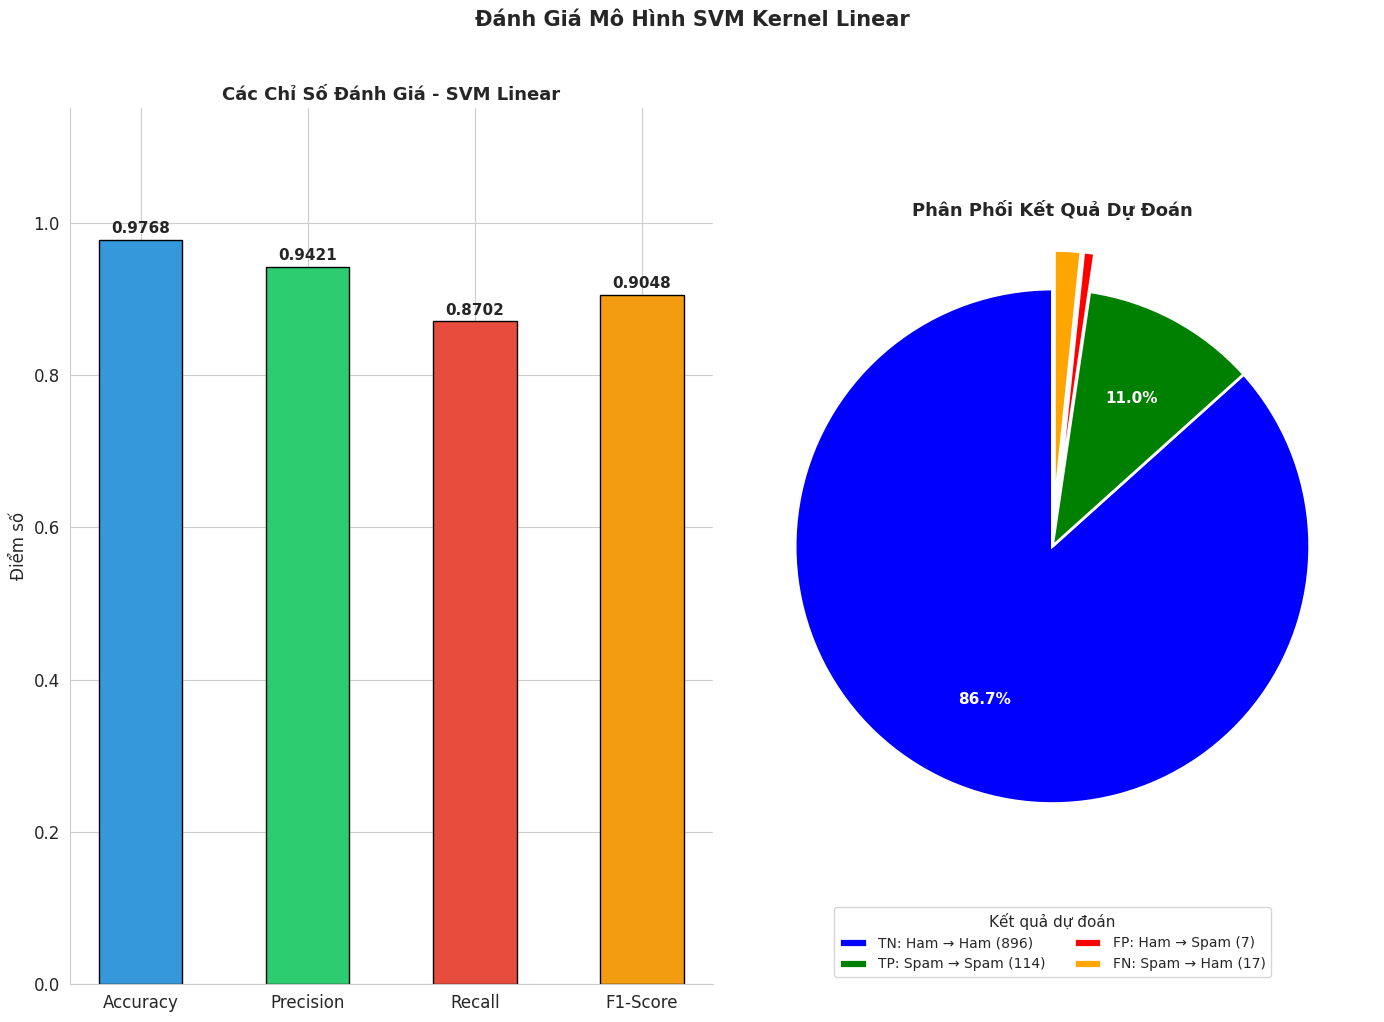

In [ ]:

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_linear).ravel()

fig = plt.figure(figsize=(14, 10))

# Biểu đồ cột
ax1 = fig.add_subplot(1, 2, 1)

chi_so  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
gia_tri = [
    accuracy_score(y_test, y_pred_linear),
    precision_score(y_test, y_pred_linear),
    recall_score(y_test, y_pred_linear),
    f1_score(y_test, y_pred_linear)
]
mau_sac = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = ax1.bar(
    chi_so, gia_tri,
    color     = mau_sac,
    edgecolor = 'black',
    width     = 0.5
)
for bar, val in zip(bars, gia_tri):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
ax1.set_title('Các Chỉ Số Đánh Giá - SVM Linear',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Điểm số')
ax1.set_ylim(0, 1.15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Biểu đồ tròn phân phối dự đoán
ax2 = fig.add_subplot(1, 2, 2)

gia_tri_tron = [tn, tp, fp, fn]
mau_tron     = ['blue', 'green', 'red', 'orange']
nhan_tron    = [
    f'TN: Ham → Ham ({tn})',
    f'TP: Spam → Spam ({tp})',
    f'FP: Ham → Spam ({fp})',
    f'FN: Spam → Ham ({fn})'
]

wedges, texts = ax2.pie(
    gia_tri_tron,
    colors     = mau_tron,
    startangle = 90,
    explode    = (0, 0, 0.15, 0.15),
    wedgeprops = dict(linewidth=2, edgecolor='white')
)

phan_tram = [v / sum(gia_tri_tron) * 100 for v in gia_tri_tron]
goc_giua  = []
for wedge in wedges:
    goc = (wedge.theta1 + wedge.theta2) / 2
    goc_giua.append(goc)

for i, (wedge, pct, goc) in enumerate(
    zip(wedges, phan_tram, goc_giua)
):
    if pct > 3:
        r    = 0.65
        x    = r * np.cos(np.deg2rad(goc))
        y    = r * np.sin(np.deg2rad(goc))
        ax2.text(
            x, y,
            f'{pct:.1f}%',
            ha         = 'center',
            va         = 'center',
            fontsize   = 11,
            fontweight = 'bold',
            color      = 'white'
        )

ax2.legend(
    wedges,
    nhan_tron,
    title          = 'Kết quả dự đoán',
    loc            = 'upper center',
    bbox_to_anchor = (0.5, -0.05),
    ncol           = 2,
    fontsize       = 10,
    title_fontsize = 11,
    frameon        = True
)
ax2.set_title('Phân Phối Kết Quả Dự Đoán',
              fontsize=13, fontweight='bold')

plt.suptitle('Đánh Giá Mô Hình SVM Kernel Linear',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


###7.4 Đường cong ROC

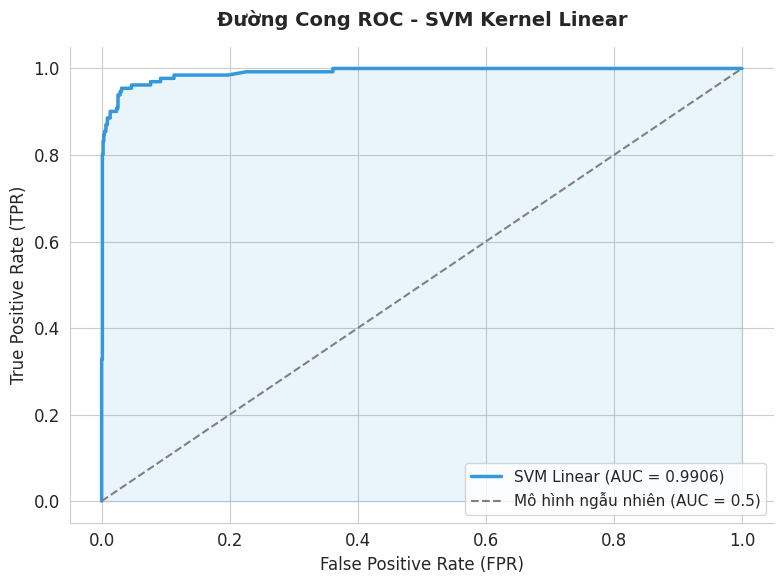


=> AUC Score: 0.9906
   AUC càng gần 1 thì mô hình càng tốt
   AUC = 0.5 tương đương đoán ngẫu nhiên


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

decision_scores = svm_linear.decision_function(X_test_tfidf)
fpr, tpr, _     = roc_curve(y_test, decision_scores)
auc_score       = roc_auc_score(y_test, decision_scores)

fig, ax = plt.subplots(figsize=(8, 6))

# Đường ROC của mô hình
ax.plot(
    fpr, tpr,
    color     = '#3498db',
    linewidth = 2.5,
    label     = f'SVM Linear (AUC = {auc_score:.4f})'
)
# Đường tham chiếu
ax.plot(
    [0, 1], [0, 1],
    color     = 'gray',
    linewidth = 1.5,
    linestyle = '--',
    label     = 'Mô hình ngẫu nhiên (AUC = 0.5)'
)
ax.fill_between(fpr, tpr, alpha=0.1, color='#3498db')

ax.set_title('Đường Cong ROC - SVM Kernel Linear',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.legend(fontsize=11, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n=> AUC Score: {auc_score:.4f}")
print(f"   AUC càng gần 1 thì mô hình càng tốt")
print(f"   AUC = 0.5 tương đương đoán ngẫu nhiên")

###7.5 Tổng kết đánh giá

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_linear).ravel()

print("TỔNG KẾT ĐÁNH GIÁ MÔ HÌNH SVM KERNEL LINEAR:")
print(f"  Accuracy   : {accuracy_score(y_test, y_pred_linear):.4f}")
print(f"  Precision  : {precision_score(y_test, y_pred_linear):.4f}")
print(f"  Recall     : {recall_score(y_test, y_pred_linear):.4f}")
print(f"  F1-Score   : {f1_score(y_test, y_pred_linear):.4f}")
print(f"  AUC Score  : {auc_score:.4f}")
print(f"\n  Tổng mẫu kiểm tra  : {len(y_test)}")
print(f"  Dự đoán đúng       : {tn + tp}")
print(f"  Dự đoán sai        : {fp + fn}")
print(f"  Spam bị bỏ sót     : {fn}")
print(f"  Ham bị nhận nhầm   : {fp}")

TỔNG KẾT ĐÁNH GIÁ MÔ HÌNH SVM KERNEL LINEAR:
  Accuracy   : 0.9768
  Precision  : 0.9421
  Recall     : 0.8702
  F1-Score   : 0.9048
  AUC Score  : 0.9906

  Tổng mẫu kiểm tra  : 1034
  Dự đoán đúng       : 1010
  Dự đoán sai        : 24
  Spam bị bỏ sót     : 17
  Ham bị nhận nhầm   : 7


#8. So sánh SVM với thuật toán khác

In [ ]:
# Naive Bayes (Thuật toán xác suất)
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

#Logistic Regression (Thuật toán hồi quy)
lr_model = LogisticRegression(
    max_iter     = 1000,
    class_weight = 'balanced',
    random_state = RANDOM_STATE
)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

### So sánh kết quả các mô hình

In [ ]:
# danh sách 3 mô hình
# Tổng hợp kết quả tất cả mô hình
danh_sach_mo_hinh = {
    'SVM Linear'           : y_pred_linear,
    'Naive Bayes'          : y_pred_nb,
    'Logistic Regression'  : y_pred_lr
}

ket_qua = []
for ten, y_pred in danh_sach_mo_hinh.items():
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, y_pred).ravel()
    ket_qua.append({
        'Mô hình'   : ten,
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred),
        'Recall'    : recall_score(y_test, y_pred),
        'F1-Score'  : f1_score(y_test, y_pred),
        'Spam bỏ sót (FN)' : fn_,
        'Ham nhầm (FP)'    : fp_
    })

df_so_sanh = pd.DataFrame(ket_qua)
df_so_sanh = df_so_sanh.set_index('Mô hình')
df_so_sanh = df_so_sanh.round(4)

display(df_so_sanh)

,Accuracy,Precision,Recall,F1-Score,Spam bỏ sót (FN),Ham nhầm (FP)
Mô hình,,,,,,
SVM Linear,0.9768,0.9421,0.8702,0.9048,17,7
Naive Bayes,0.9652,0.9897,0.7328,0.8421,35,1
Logistic Regression,0.9739,0.9062,0.8855,0.8958,15,12


### So sánh các chỉ số

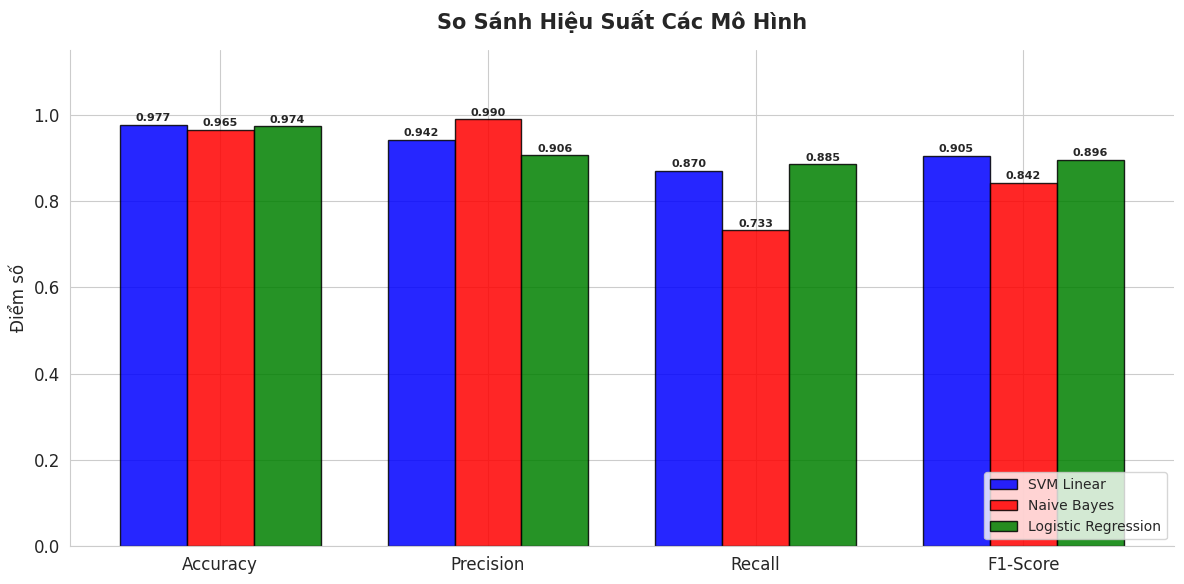

In [ ]:
# Biểu đồ so sánh 4 chỉ số chính
chi_so_ve   = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
mau_mo_hinh = ['blue', 'red', 'green']
ten_mo_hinh = list(danh_sach_mo_hinh.keys())

fig, ax = plt.subplots(figsize=(12, 6))

x     = np.arange(len(chi_so_ve))
width = 0.25

for i, (ten, mau) in enumerate(zip(ten_mo_hinh, mau_mo_hinh)):
    gia_tri = df_so_sanh.loc[ten, chi_so_ve].values
    bars    = ax.bar(
        x + i * width,
        gia_tri,
        width,
        label     = ten,
        color     = mau,
        edgecolor = 'black',
        alpha     = 0.85
    )
    # Thêm số liệu lên đầu mỗi cột
    for bar, val in zip(bars, gia_tri):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

ax.set_title('So Sánh Hiệu Suất Các Mô Hình',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(chi_so_ve, fontsize=12)
ax.set_ylabel('Điểm số', fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10, loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### So sánh số lượng lỗi

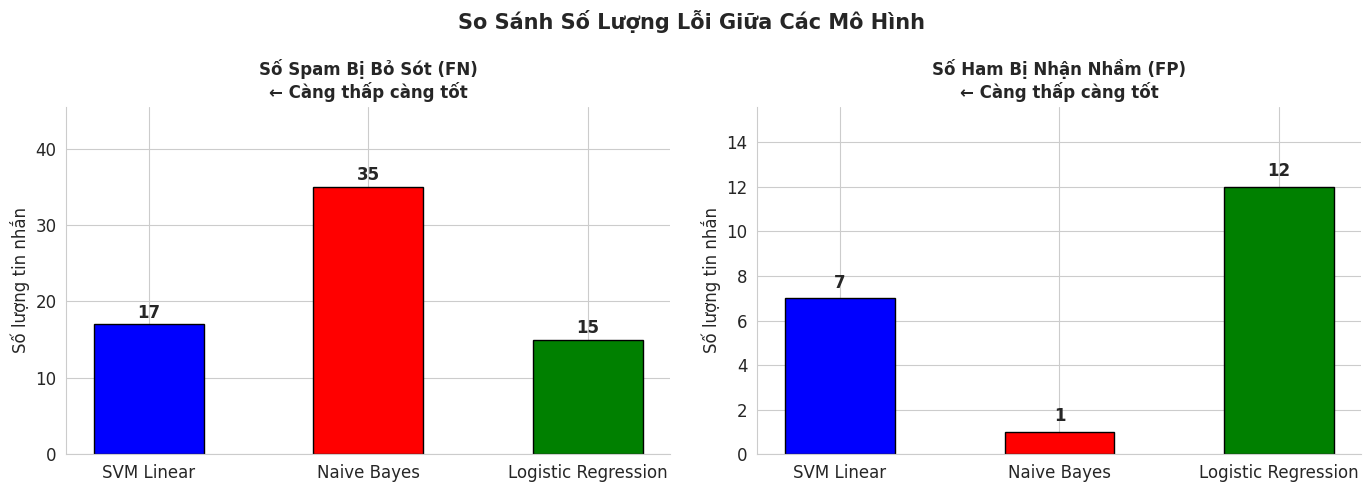

In [ ]:
# Biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fn_values = df_so_sanh['Spam bỏ sót (FN)'].values
fp_values = df_so_sanh['Ham nhầm (FP)'].values
mau_loi   = ['blue', 'red', 'green']

# Biểu đồ FN
bars_fn = axes[0].bar(
    ten_mo_hinh,
    fn_values,
    color     = mau_loi,
    edgecolor = 'black',
    width     = 0.5
)
for bar, val in zip(bars_fn, fn_values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(int(val)),
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )
axes[0].set_title('Số Spam Bị Bỏ Sót (FN)\n← Càng thấp càng tốt',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số lượng tin nhắn')
axes[0].set_ylim(0, max(fn_values) * 1.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Biểu đồ FP
bars_fp = axes[1].bar(
    ten_mo_hinh,
    fp_values,
    color     = mau_loi,
    edgecolor = 'black',
    width     = 0.5
)
for bar, val in zip(bars_fp, fp_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        str(int(val)),
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )
axes[1].set_title('Số Ham Bị Nhận Nhầm (FP)\n← Càng thấp càng tốt',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Số lượng tin nhắn')
axes[1].set_ylim(0, max(fp_values) * 1.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('So Sánh Số Lượng Lỗi Giữa Các Mô Hình',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### Kết luận mô hình tốt nhất

In [ ]:
mo_hinh_tot_nhat = df_so_sanh['F1-Score'].idxmax()

print("TỔNG KẾT SO SÁNH CÁC MÔ HÌNH:")
for ten in ten_mo_hinh:
    print(f"\n  {ten}:")
    print(f"    Accuracy  : {df_so_sanh.loc[ten, 'Accuracy']:.4f}")
    print(f"    Precision : {df_so_sanh.loc[ten, 'Precision']:.4f}")
    print(f"    Recall    : {df_so_sanh.loc[ten, 'Recall']:.4f}")
    print(f"    F1-Score  : {df_so_sanh.loc[ten, 'F1-Score']:.4f}")
    print(f"    Spam bỏ sót (FN) : "
          f"{int(df_so_sanh.loc[ten, 'Spam bỏ sót (FN)'])}")
    print(f"    Ham nhầm   (FP)  : "
          f"{int(df_so_sanh.loc[ten, 'Ham nhầm (FP)'])}")
print(f"\n Mô hình tốt nhất theo F1-Score: {mo_hinh_tot_nhat}")
print(f"   F1-Score: {df_so_sanh.loc[mo_hinh_tot_nhat, 'F1-Score']:.4f}")


TỔNG KẾT SO SÁNH CÁC MÔ HÌNH:

  SVM Linear:
    Accuracy  : 0.9768
    Precision : 0.9421
    Recall    : 0.8702
    F1-Score  : 0.9048
    Spam bỏ sót (FN) : 17
    Ham nhầm   (FP)  : 7

  Naive Bayes:
    Accuracy  : 0.9652
    Precision : 0.9897
    Recall    : 0.7328
    F1-Score  : 0.8421
    Spam bỏ sót (FN) : 35
    Ham nhầm   (FP)  : 1

  Logistic Regression:
    Accuracy  : 0.9739
    Precision : 0.9062
    Recall    : 0.8855
    F1-Score  : 0.8958
    Spam bỏ sót (FN) : 15
    Ham nhầm   (FP)  : 12

 Mô hình tốt nhất theo F1-Score: SVM Linear
   F1-Score: 0.9048


##9. GridSearch

###9.1 Thiết lập

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
# Thiết lập các tham số cần thử
param_grid = {
    'C' : [0.01, 0.1, 1, 10, 100]
}

# Khởi tạo GridSearchCV
grid_search = GridSearchCV(
    estimator  = SVC(
        kernel       = 'linear',
        class_weight = 'balanced',
        random_state = RANDOM_STATE
    ),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)

print(f"Số tổ hợp tham số cần thử : {len(param_grid['C'])}")
print(f"Số fold Cross Validation  : 5")
print(f"Tổng số lần huấn luyện    : {len(param_grid['C']) * 5}")


Số tổ hợp tham số cần thử : 5
Số fold Cross Validation  : 5
Tổng số lần huấn luyện    : 25


In [ ]:
#chạy thử
grid_search.fit(X_train_tfidf, y_train)

print(f"Tham số tốt nhất : C = {grid_search.best_params_['C']}")
print(f"F1-Score tốt nhất: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Tham số tốt nhất : C = 1
F1-Score tốt nhất: 0.9021


In [ ]:
# kết quả chi tiết
ket_qua_grid = pd.DataFrame({
    'Giá trị C'         : param_grid['C'],
    'F1-Score TB'       : grid_search.cv_results_['mean_test_score'],
    'Độ lệch chuẩn'     : grid_search.cv_results_['std_test_score']
}).round(4)

ket_qua_grid = ket_qua_grid.sort_values(
    'F1-Score TB', ascending=False
).reset_index(drop=True)
ket_qua_grid.insert(0, 'Xếp hạng', range(1, len(ket_qua_grid) + 1))

display(ket_qua_grid)

,Xếp hạng,Giá trị C,F1-Score TB,Độ lệch chuẩn
0,1,1.00,0.9021,0.0193
1,2,100.00,0.8988,0.0163
2,3,10.00,0.8979,0.0160
3,4,0.10,0.8840,0.0134
4,5,0.01,0.2243,0.0009


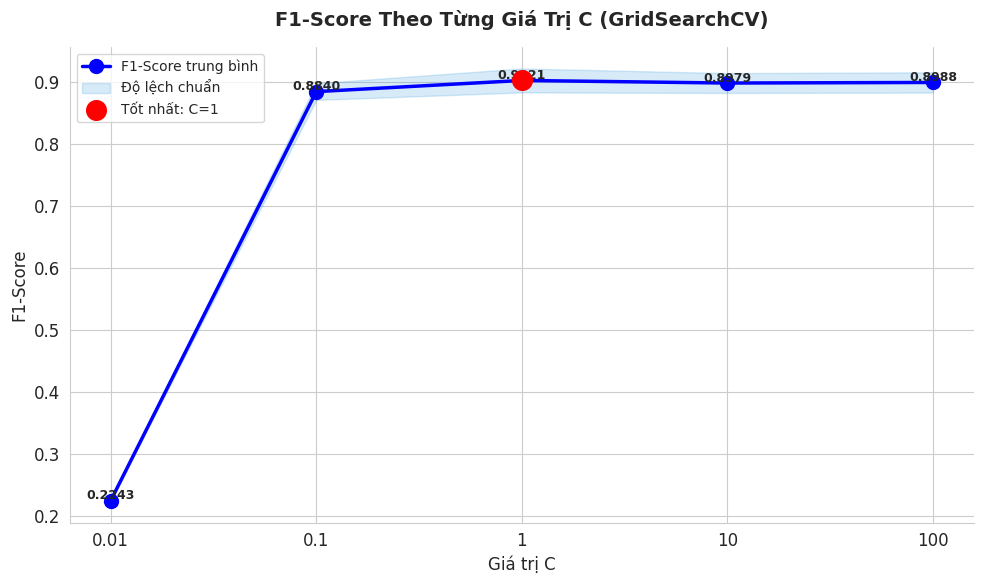

In [ ]:
# biểu đồ kết quả
mean_scores = grid_search.cv_results_['mean_test_score']
std_scores  = grid_search.cv_results_['std_test_score']
c_values    = param_grid['C']

fig, ax = plt.subplots(figsize=(10, 6))

# Đường F1-Score
ax.plot(
    range(len(c_values)),
    mean_scores,
    marker    = 'o',
    color     = 'blue',
    linewidth = 2.5,
    markersize= 10,
    label     = 'F1-Score trung bình'
)
# Vùng độ lệch chuẩn
ax.fill_between(
    range(len(c_values)),
    mean_scores - std_scores,
    mean_scores + std_scores,
    alpha = 0.2,
    color = '#3498db',
    label = 'Độ lệch chuẩn'
)

# Đánh dấu điểm tốt nhất
best_idx = mean_scores.argmax()
ax.scatter(
    best_idx,
    mean_scores[best_idx],
    color  = 'red',
    s      = 200,
    zorder = 5,
    label  = f'Tốt nhất: C={c_values[best_idx]}'
)
# Thêm số liệu lên từng điểm
for i, (score, c) in enumerate(zip(mean_scores, c_values)):
    ax.text(
        i, score + 0.002,
        f'{score:.4f}',
        ha         = 'center',
        fontsize   = 9,
        fontweight = 'bold'
    )

ax.set_title('F1-Score Theo Từng Giá Trị C (GridSearchCV)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Giá trị C', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_xticks(range(len(c_values)))
ax.set_xticklabels([str(c) for c in c_values])
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Đánh giá mô hình sau tối ưu

In [ ]:
# Dự đoán mô hình tốt nhất
svm_toi_uu   = grid_search.best_estimator_
y_pred_toi_uu = svm_toi_uu.predict(X_test_tfidf)

# So sánh trước và sau
ket_qua_truoc = {
    'Accuracy'  : accuracy_score(y_test, y_pred_linear),
    'Precision' : precision_score(y_test, y_pred_linear),
    'Recall'    : recall_score(y_test, y_pred_linear),
    'F1-Score'  : f1_score(y_test, y_pred_linear)
}
ket_qua_sau = {
    'Accuracy'  : accuracy_score(y_test, y_pred_toi_uu),
    'Precision' : precision_score(y_test, y_pred_toi_uu),
    'Recall'    : recall_score(y_test, y_pred_toi_uu),
    'F1-Score'  : f1_score(y_test, y_pred_toi_uu)
}

df_truoc_sau = pd.DataFrame({
    'Trước tối ưu (C=1)'                          : ket_qua_truoc,
    f'Sau tối ưu (C={grid_search.best_params_["C"]})' : ket_qua_sau
}).round(4)

df_truoc_sau['Thay đổi'] = (
    df_truoc_sau[f'Sau tối ưu (C={grid_search.best_params_["C"]})']
    - df_truoc_sau['Trước tối ưu (C=1)']
).round(4)

display(df_truoc_sau)


,Trước tối ưu (C=1),Sau tối ưu (C=1),Thay đổi
Accuracy,0.9768,0.9768,0.0
Precision,0.9421,0.9421,0.0
Recall,0.8702,0.8702,0.0
F1-Score,0.9048,0.9048,0.0


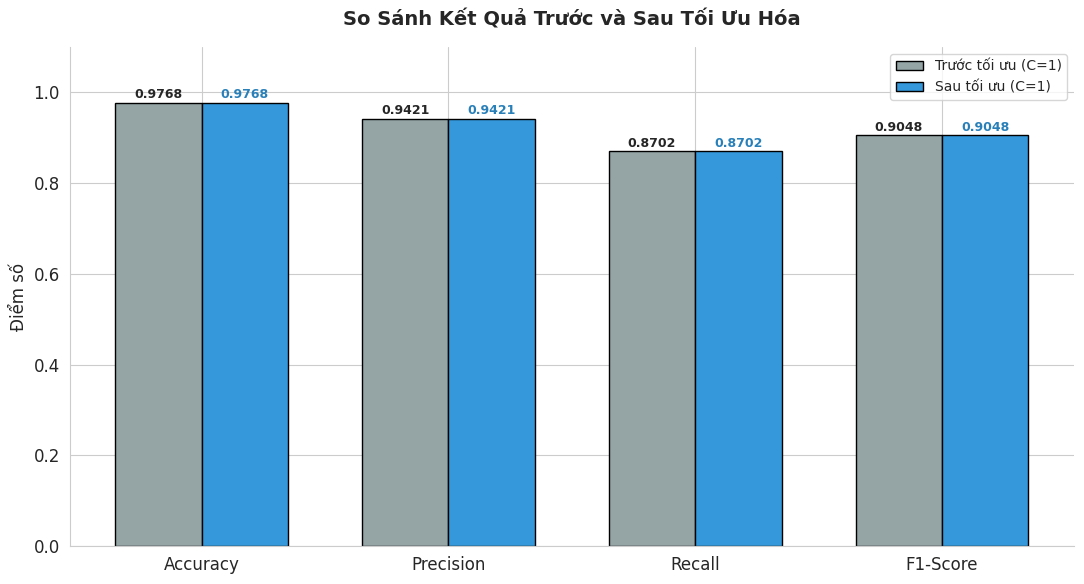


 Tham số tốt nhất tìm được: C = 1
F1-Score sau tối ưu      : 0.9048
Cải thiện F1-Score       : +0.0000


In [ ]:
# so sánh dưới dạng biểu đồ
chi_so_ve = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x         = np.arange(len(chi_so_ve))
width     = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(
    x - width / 2,
    list(ket_qua_truoc.values()),
    width,
    label     = 'Trước tối ưu (C=1)',
    color     = '#95a5a6',
    edgecolor = 'black'
)
bars2 = ax.bar(
    x + width / 2,
    list(ket_qua_sau.values()),
    width,
    label     = f'Sau tối ưu (C={grid_search.best_params_["C"]})',
    color     = '#3498db',
    edgecolor = 'black'
)
# Thêm số liệu lên đầu mỗi cột
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.4f}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#2980b9'
    )

ax.set_title('So Sánh Kết Quả Trước và Sau Tối Ưu Hóa',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(chi_so_ve, fontsize=12)
ax.set_ylabel('Điểm số', fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\n Tham số tốt nhất tìm được: C = {grid_search.best_params_['C']}")
print(f"F1-Score sau tối ưu      : {ket_qua_sau['F1-Score']:.4f}")
print(f"Cải thiện F1-Score       : "
      f"{ket_qua_sau['F1-Score'] - ket_qua_truoc['F1-Score']:+.4f}")


# 10. Dự đoán tin nhắn mới

##10.1 Hàm dự đoán

In [ ]:
def du_doan_tin_nhan(tin_nhan):
    tin_sach    = lam_sach_van_ban(tin_nhan)
    vector      = tfidf.transform([tin_sach])
    ket_qua     = svm_toi_uu.predict(vector)[0]
    do_tin_cay  = abs(svm_toi_uu.decision_function(vector)[0])
    return ket_qua, do_tin_cay


In [ ]:
# Tin nhắn mẫu
# ham: 0, spam: 1
tin_nhan_mau = [
    # Tin nhắn ham
    {
        'noi_dung' : "Hey, are you coming to dinner tonight?",
        'nhan_that': 0
    },
    {
        'noi_dung' : "I will call you back in 10 minutes",
        'nhan_that': 0
    },
    {
        'noi_dung' : "Ok sounds good, see you tomorrow morning. If you have freetime, give it back to me as soon as possible",
        'nhan_that': 0
    },
    {
        'noi_dung' : "Thanks for the birthday wishes! I had a great time",
        'nhan_that': 0
    },
    {
        'noi_dung' : "Can you send me the homework for tomorrow please",
        'nhan_that': 0
    },

    # Tin nhắn spam
    {
        'noi_dung' : "FREE entry! Win a £1000 cash prize. Call 09061702893 NOW!!!",
        'nhan_that': 1
    },
    {
        'noi_dung' : "Congratulations! You have been selected to receive a FREE mobile phone",
        'nhan_that': 1
    },
    {
        'noi_dung' : "URGENT! Your account will be suspended. Call 0800123456 immediately",
        'nhan_that': 1
    },
    {
        'noi_dung' : "You have won a 2 week holiday worth £5000! Text WIN to 87099",
        'nhan_that': 1
    },
    {
        'noi_dung' : "Get a FREE ringtone! Text TONE to 80488. Only £3 per week",
        'nhan_that': 1
    }
]


###10.2 Chạy dự đoán

In [ ]:
ket_qua_demo = []

for i, tin in enumerate(tin_nhan_mau):
    nhan_so, do_tin_cay = du_doan_tin_nhan(tin['noi_dung'])

    nhan_that_hien    = 'HAM'  if tin['nhan_that'] == 0 else 'SPAM'
    nhan_du_doan_hien = 'HAM'  if nhan_so == 0          else 'SPAM'
    dung_sai          = 'Dung' if nhan_so == tin['nhan_that'] else 'Sai'

    ket_qua_demo.append({
        'STT'          : i + 1,
        'Tin nhan'     : tin['noi_dung'][:45] + '...'
                         if len(tin['noi_dung']) > 45
                         else tin['noi_dung'],
        'Nhan that'    : nhan_that_hien,
        'Nhan du doan' : nhan_du_doan_hien,
        'Do tin cay'   : round(do_tin_cay, 4),
        'Ket qua'      : dung_sai
    })

df_demo = pd.DataFrame(ket_qua_demo).set_index('STT')

print("KET QUA DU DOAN")
display(df_demo)

so_dung = sum(1 for k in ket_qua_demo if k['Ket qua'] == 'Dung')
print(f"\nDu doan dung: {so_dung}/{len(tin_nhan_mau)} tin nhan")
print(f"Do chinh xac: {so_dung/len(tin_nhan_mau)*100:.0f}%")


KET QUA DU DOAN


,Tin nhan,Nhan that,Nhan du doan,Do tin cay,Ket qua
STT,,,,,
1,"Hey, are you coming to dinner tonight?",HAM,HAM,1.4759,Dung
2,I will call you back in 10 minutes,HAM,HAM,1.3364,Dung
3,"Ok sounds good, see you tomorrow morning. If ...",HAM,HAM,1.7651,Dung
4,Thanks for the birthday wishes! I had a great...,HAM,HAM,1.0203,Dung
5,Can you send me the homework for tomorrow ple...,HAM,HAM,0.8131,Dung
6,FREE entry! Win a £1000 cash prize. Call 0906...,SPAM,SPAM,1.1073,Dung
7,Congratulations! You have been selected to re...,SPAM,SPAM,1.3640,Dung
8,URGENT! Your account will be suspended. Call ...,SPAM,SPAM,0.0914,Dung
9,You have won a 2 week holiday worth £5000! Te...,SPAM,SPAM,1.7975,Dung



Du doan dung: 10/10 tin nhan
Do chinh xac: 100%


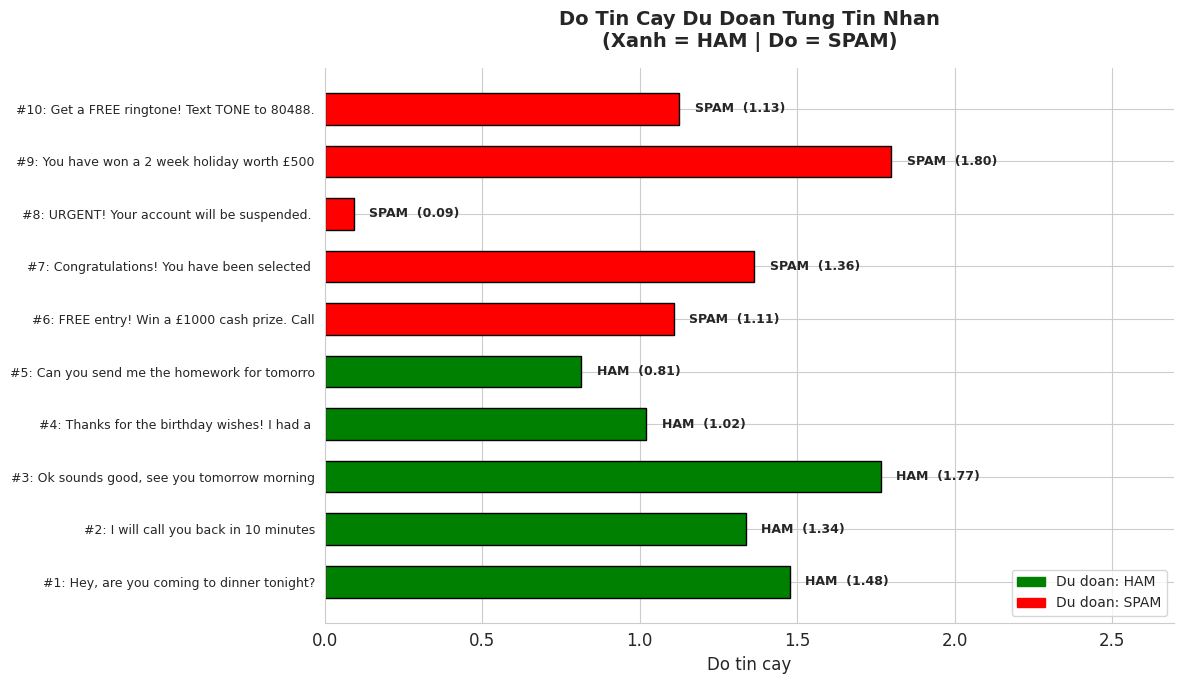

In [ ]:
# Biểu đồ tin cậy
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 7))

mau_bars  = ['red' if k['Nhan du doan'] == 'SPAM'
             else 'green'
             for k in ket_qua_demo]

nhan_bars = [f"#{k['STT']}: {k['Tin nhan'][:40]}"
             for k in ket_qua_demo]

bars = ax.barh(
    range(len(ket_qua_demo)),
    [k['Do tin cay'] for k in ket_qua_demo],
    color     = mau_bars,
    edgecolor = 'black',
    height    = 0.6
)

# nhãn dự đoán
for bar, k in zip(bars, ket_qua_demo):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{k['Nhan du doan']}  ({k['Do tin cay']:.2f})",
        va='center', ha='left',
        fontsize=9, fontweight='bold'
    )

ax.set_yticks(range(len(ket_qua_demo)))
ax.set_yticklabels(nhan_bars, fontsize=9)
ax.set_xlabel('Do tin cay', fontsize=12)
ax.set_title('Do Tin Cay Du Doan Tung Tin Nhan\n'
             '(Xanh = HAM | Do = SPAM)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, max(k['Do tin cay']
            for k in ket_qua_demo) * 1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend = [
    Patch(color='green', label='Du doan: HAM'),
    Patch(color='red', label='Du doan: SPAM')
]
ax.legend(handles=legend, fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()


### Nhập tin nhắn tùy ý để thử

In [ ]:
# Nhập số lượng tin nhắn muốn thử
so_luong = int(input("\nBan muon thu bao nhieu tin nhan? "))
print(f"Ban se nhap {so_luong} tin nhan.\n")

# Nhập lần lượt từng tin nhắn
danh_sach_tin = []
for i in range(so_luong):
    tin = input(f"Nhap tin nhan {i+1}: ")
    danh_sach_tin.append(tin)

# Dự đoán và hiển thị kết quả
print("\n" + "-" * 55)
print("         KET QUA DU DOAN")
print("-" * 55)

ket_qua_nhap = []
for i, tin in enumerate(danh_sach_tin):
    nhan_so, do_tin_cay = du_doan_tin_nhan(tin)
    nhan_hien = 'HAM' if nhan_so == 0 else 'SPAM'

    if do_tin_cay >= 1.5:
        muc_do = 'Rat chac chan'
    elif do_tin_cay >= 0.5:
        muc_do = 'Kha chac chan'
    else:
        muc_do = 'Phan van'

    ket_qua_nhap.append({
        'STT'          : i + 1,
        'Tin nhan'     : tin[:45] + '...'
                         if len(tin) > 45 else tin,
        'Du doan'      : nhan_hien,
        'Do tin cay'   : round(do_tin_cay, 4),
        'Muc do'       : muc_do
    })

    print(f"\n  [{i+1}] Tin nhan  : {tin}")
    print(f"      Du doan   : {nhan_hien}")
    print(f"      Do tin cay: {do_tin_cay:.4f}")
    print(f"      Muc do    : {muc_do}")
    print(f"      {'-' * 45}")

# Tổng kết
so_spam = sum(1 for k in ket_qua_nhap if k['Du doan'] == 'SPAM')
so_ham  = sum(1 for k in ket_qua_nhap if k['Du doan'] == 'HAM')

print(f"\n{'-' * 55}")
print(f"  Tong so tin nhan : {so_luong}")
print(f"  HAM              : {so_ham}")
print(f"  SPAM             : {so_spam}")
print(f"{'-' * 55}")



Ban muon thu bao nhieu tin nhan? 4
Ban se nhap 4 tin nhan.

Nhap tin nhan 1: Gemini 3 has arrived - our most capable and efficient model yet. We have a big deal to you, contact for more
Nhap tin nhan 2: Sale up to 80%. We provide to you huge product on our shop
Nhap tin nhan 3: I'm afraid that i will be late the party. Don't waiting for me
Nhap tin nhan 4: Do you have free time tonight my darling ?

-------------------------------------------------------
         KET QUA DU DOAN
-------------------------------------------------------

  [1] Tin nhan  : Gemini 3 has arrived - our most capable and efficient model yet. We have a big deal to you, contact for more
      Du doan   : HAM
      Do tin cay: 0.9572
      Muc do    : Kha chac chan
      ---------------------------------------------

  [2] Tin nhan  : Sale up to 80%. We provide to you huge product on our shop
      Du doan   : HAM
      Do tin cay: 0.2445
      Muc do    : Phan van
      ------------------------------------------

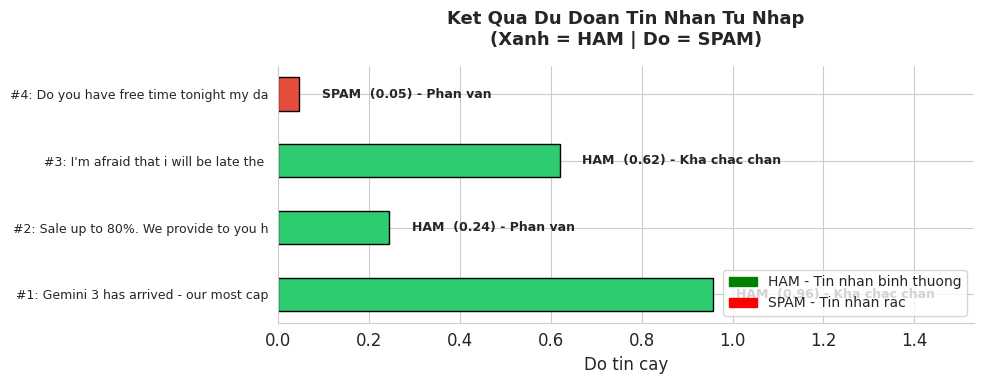

In [ ]:
# Biểu đồ kết quả
if len(ket_qua_nhap) > 0:
    from matplotlib.patches import Patch

    fig, ax = plt.subplots(figsize=(10, max(4, len(ket_qua_nhap) * 0.8)))

    mau_bars  = ['#e74c3c' if k['Du doan'] == 'SPAM'
                 else '#2ecc71'
                 for k in ket_qua_nhap]
    nhan_bars = [f"#{k['STT']}: {k['Tin nhan'][:35]}"
                 for k in ket_qua_nhap]

    bars = ax.barh(
        range(len(ket_qua_nhap)),
        [k['Do tin cay'] for k in ket_qua_nhap],
        color     = mau_bars,
        edgecolor = 'black',
        height    = 0.5
    )

    for bar, k in zip(bars, ket_qua_nhap):
        ax.text(
            bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{k['Du doan']}  ({k['Do tin cay']:.2f}) - {k['Muc do']}",
            va='center', ha='left',
            fontsize=9, fontweight='bold'
        )

    ax.set_yticks(range(len(ket_qua_nhap)))
    ax.set_yticklabels(nhan_bars, fontsize=9)
    ax.set_xlabel('Do tin cay', fontsize=12)
    ax.set_title('Ket Qua Du Doan Tin Nhan Tu Nhap\n'
                 '(Xanh = HAM | Do = SPAM)',
                 fontsize=13, fontweight='bold', pad=15)
    ax.set_xlim(0, max(k['Do tin cay']
                for k in ket_qua_nhap) * 1.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    legend = [
        Patch(color='green', label='HAM - Tin nhan binh thuong'),
        Patch(color='red', label='SPAM - Tin nhan rac')
    ]
    ax.legend(handles=legend, fontsize=10, loc='lower right')

    plt.tight_layout()
    plt.show()
